# 🏨 Hotel Booking Analytics: Understanding Revenue Drivers & Customer Behaviour

**Author:** Benard Mwinzi  
**Dataset:** International Hotel Bookings (2010–2019) | 66,541 records  
**Data Source:** [kaggle Platform](https://www.kaggle.com/code/benardmwinzi/hotel-bookings-eda/input?select=Hotel_Dataset.csv)

**Tools:** Python · Pandas · Matplotlib · Seaborn · Plotly

---

## 1. Business Problem

**DreamDest** is a Singapore-based online travel agency (OTA) that facilitates international hotel bookings for travellers across Southeast Asia. Despite consistent booking growth since 2010, the business leadership has raised the following concerns:

> *"We have years of booking data but limited visibility into what's actually driving revenue and profit. We don't know which customer segments are most valuable, which destinations perform best, or whether our discount strategy is helping or hurting margins."*

### Business Questions

This analysis seeks to answer **five key questions**:

| # | Question | Stakeholder |
|---|----------|-------------|
| 1 | Which origin markets and destinations drive the most bookings and revenue? | Marketing & Sales |
| 2 | What does the typical agency customer look like? | Product & CX |
| 3 | How have bookings and revenue trended over time? | Executive Leadership |
| 4 | What is the relationship between discounts and profit margins? | Finance |
| 5 | Which hotel ratings and booking durations are most associated with higher revenue? | Partnerships |

---

## 2. Setup & Data Loading

In [1]:
# ── Core Libraries ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# ── Plot Styling ───────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
PALETTE   = ['#2C7BB6', '#D7191C', '#1A9641', '#FDAE61', '#7B2D8B']
BLUE      = '#2C7BB6'
HIGHLIGHT = '#D7191C'
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print('Libraries loaded successfully ✓')

Libraries loaded successfully ✓


In [2]:
# ── Load Dataset 
df = pd.read_csv(r'D:\Python\Hotel Bookings Project\Hotel_Dataset.csv', encoding='latin1')

# Checking the dataset shape
print(f'Dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns')

Dataset shape : 66,541 rows × 24 columns


In [3]:
# checkin the first 5 rows of the dataset.
df.head()

,Booking ID,Date of Booking,Time,Customer ID,Gender,Age,Origin Country,State,Location,Destination Country,...,Check-Out Date,Rooms,Hotel Name,Hotel Rating,Payment Mode,Bank Name,Booking Price[SGD],Discount,GST,Profit Margin
0,DDMY00001,1/1/2010,10:49:40,MY00001,Male,42,Malaysia,Johor,Iskandar Puteri,Denmark,...,1/20/2010,1,Hotel Triton,4.3,Wallet,United Overseas Bank (UOB),243,1%,0.07,0.25
1,DDID00002,1/1/2010,9:19:47,ID00001,Female,44,Indonesia,Ciawi,West Java,Colombia,...,1/22/2010,2,Enchanted Isle,4.2,Wallet,EZ-Link,312,0%,0.07,0.24
2,DDSG00003,1/1/2010,11:52:56,SG00001,Female,31,Singapore,Central,Rochor,Germany,...,1/9/2010,2,Seacoast Hotel,4.5,Credit Card,Grab,338,19%,0.07,0.20
3,DDSG00004,1/1/2010,13:44:40,SG00002,Male,28,Singapore,North,Yishun,Canada,...,2/19/2010,2,Night In Paradise,4.2,Debit Card,DBS Paylah,254,19%,0.07,0.13
4,DDKH00005,1/1/2010,5:38:26,KH00001,Male,44,Cambodia,Phnom Trop,Pursat,Kenya,...,1/6/2010,3,Tiny Digs Hotel,4.6,Wallet,Bank of Singapore (BOS),313,15%,0.07,0.17


### Data Dictionary

| Column | Description |
|--------|-------------|
| `Booking ID` | Unique identifier for each booking |
| `Date of Booking` | Date the booking was made |
| `Customer ID` | Unique customer identifier |
| `Gender` | Customer gender |
| `Age` | Customer age |
| `Origin Country` | Country the traveller is from |
| `Destination Country` | Country the traveller is travelling to |
| `Destination City` | City within the destination country |
| `No. Of People` | Group size |
| `Check-in date` | Hotel check-in date |
| `No of Days` | Length of stay (nights) |
| `Rooms` | Number of rooms booked |
| `Hotel Name` | Name of the hotel |
| `Hotel Rating` | Hotel star/quality rating (out of 5) |
| `Payment Mode` | Payment method used |
| `Bank Name` | Bank or wallet used |
| `Booking Price[SGD]` | Price charged per night in Singapore Dollars |
| `Discount` | Discount applied to booking (%) |
| `GST` | Goods & Services Tax rate applied |
| `Profit Margin` | Net profit margin for the booking |

## 3. Data Cleaning & Feature Engineering

In [4]:
# ── Missing Values 
print('=== Missing Values ===')
print(df.isnull().sum())

=== Missing Values ===
Booking ID             0
Date of Booking        0
Time                   0
Customer ID            0
Gender                 0
Age                    0
Origin Country         0
State                  0
Location               0
Destination Country    0
Destination City       0
No. Of People          0
Check-in date          0
No of Days             0
Check-Out Date         0
Rooms                  0
Hotel Name             0
Hotel Rating           0
Payment Mode           0
Bank Name              0
Booking Price[SGD]     0
Discount               0
GST                    0
Profit Margin          0
dtype: int64


In [5]:
# ── Duplicate Rows
print(f'\nDuplicate rows: {df.duplicated().sum()}')


Duplicate rows: 5


In [6]:
# ── Data Types 
print('\n=== Data Types ===')
print(df.dtypes)


=== Data Types ===
Booking ID                 str
Date of Booking            str
Time                       str
Customer ID                str
Gender                     str
Age                      int64
Origin Country             str
State                      str
Location                   str
Destination Country        str
Destination City           str
No. Of People            int64
Check-in date              str
No of Days               int64
Check-Out Date             str
Rooms                    int64
Hotel Name                 str
Hotel Rating           float64
Payment Mode               str
Bank Name                  str
Booking Price[SGD]       int64
Discount                   str
GST                    float64
Profit Margin          float64
dtype: object


In [7]:
# ── Fixing Data Types
df['Date of Booking'] = pd.to_datetime(df['Date of Booking'], format='%m/%d/%Y')
df['Check-in date']   = pd.to_datetime(df['Check-in date'],   format='%m/%d/%Y')
df['Check-Out Date']  = pd.to_datetime(df['Check-Out Date'],  format='%m/%d/%Y')

In [8]:
# Converting Discount from string '19%' → float 0.19
df['Discount_pct'] = df['Discount'].str.replace('%', '').astype(float) / 100

In [9]:
# ── Fixing Age Anomaly (negative ages)
n_neg_age = (df['Age'] < 0).sum()
print(f'Records with negative Age: {n_neg_age}')
df['Age'] = df['Age'].abs()   # treat as data entry error — flip sign


Records with negative Age: 1


In [10]:
# ── Feature Engineering 
df['Year']          = df['Date of Booking'].dt.year
df['Month']         = df['Date of Booking'].dt.month
df['Month_Name']    = df['Date of Booking'].dt.strftime('%b')
df['Quarter']       = df['Date of Booking'].dt.quarter
df['DayOfWeek']     = df['Date of Booking'].dt.day_name()

In [11]:
# Revenue = Price after discount, inclusive of GST
df['Revenue_SGD']   = df['Booking Price[SGD]'] * (1 - df['Discount_pct']) * (1 + df['GST'])

In [12]:
# Total trip revenue (per-night rate × nights stayed)
df['Trip_Revenue']  = df['Revenue_SGD'] * df['No of Days']

In [13]:
# Profit
df['Profit_SGD']    = df['Revenue_SGD'] * df['Profit Margin']

In [14]:
# Age bands
df['Age_Group'] = pd.cut(df['Age'],
                          bins=[0, 25, 35, 45, 60],
                          labels=['18–25', '26–35', '36–45', '46–60'])

In [15]:
print('Feature engineering complete ✓')
print(f'Final dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')

Feature engineering complete ✓
Final dataset: 66,541 rows × 34 columns


## 4. Exploratory Data Analysis

### 4.1 Dataset Overview

In [16]:
# ── High-Level KPIs
total_bookings  = len(df)
total_revenue   = df['Revenue_SGD'].sum()
total_profit    = df['Profit_SGD'].sum()
avg_stay        = df['No of Days'].mean()
avg_booking_val = df['Revenue_SGD'].mean()
avg_margin      = df['Profit Margin'].mean()
date_range      = f"{df['Date of Booking'].min().year} – {df['Date of Booking'].max().year}"

print('=' * 50)
print('        DreamDest BUSINESS SNAPSHOT')
print('=' * 50)
print(f'  Period               : {date_range}')
print(f'  Total Bookings       : {total_bookings:>10,}')
print(f'  Total Revenue (SGD)  : {total_revenue:>10,.0f}')
print(f'  Total Profit  (SGD)  : {total_profit:>10,.0f}')
print(f'  Avg. Booking Value   : SGD {avg_booking_val:>7.2f}')
print(f'  Avg. Profit Margin   : {avg_margin*100:>9.1f}%')
print(f'  Avg. Length of Stay  : {avg_stay:>8.1f} nights')
print('=' * 50)

        DreamDest BUSINESS SNAPSHOT
  Period               : 2010 – 2019
  Total Bookings       :     66,541
  Total Revenue (SGD)  : 13,329,265
  Total Profit  (SGD)  :  2,458,974
  Avg. Booking Value   : SGD  200.32
  Avg. Profit Margin   :      18.9%
  Avg. Length of Stay  :      3.2 nights


In [17]:
# ── Numeric Summary ─────────────────────────────────────────────────────────────
num_cols = ['Age', 'No. Of People', 'No of Days', 'Rooms',
            'Hotel Rating', 'Booking Price[SGD]', 'Discount_pct',
            'Revenue_SGD', 'Profit Margin']
df[num_cols].describe().round(2)

,Age,No. Of People,No of Days,Rooms,Hotel Rating,Booking Price[SGD],Discount_pct,Revenue_SGD,Profit Margin
count,66541.00,66541.0,66541.00,66541.00,66541.00,66541.00,66541.00,66541.00,66541.00
mean,38.44,4.0,3.23,2.28,4.29,214.05,0.13,200.32,0.19
std,11.56,2.0,3.38,1.03,0.28,108.13,0.08,103.06,0.05
min,5.00,1.0,1.00,1.00,3.30,35.00,0.00,28.09,0.10
25%,28.00,2.0,1.00,1.00,4.20,125.00,0.06,116.84,0.14
50%,38.00,4.0,2.00,2.00,4.30,199.00,0.13,185.28,0.20
75%,48.00,6.0,4.00,3.00,4.50,293.00,0.19,275.61,0.23
max,58.00,7.0,97.00,4.00,4.70,578.00,0.25,607.76,0.30


---
### 4.2 Customer Demographics

*Who are DreamDest's customers?*

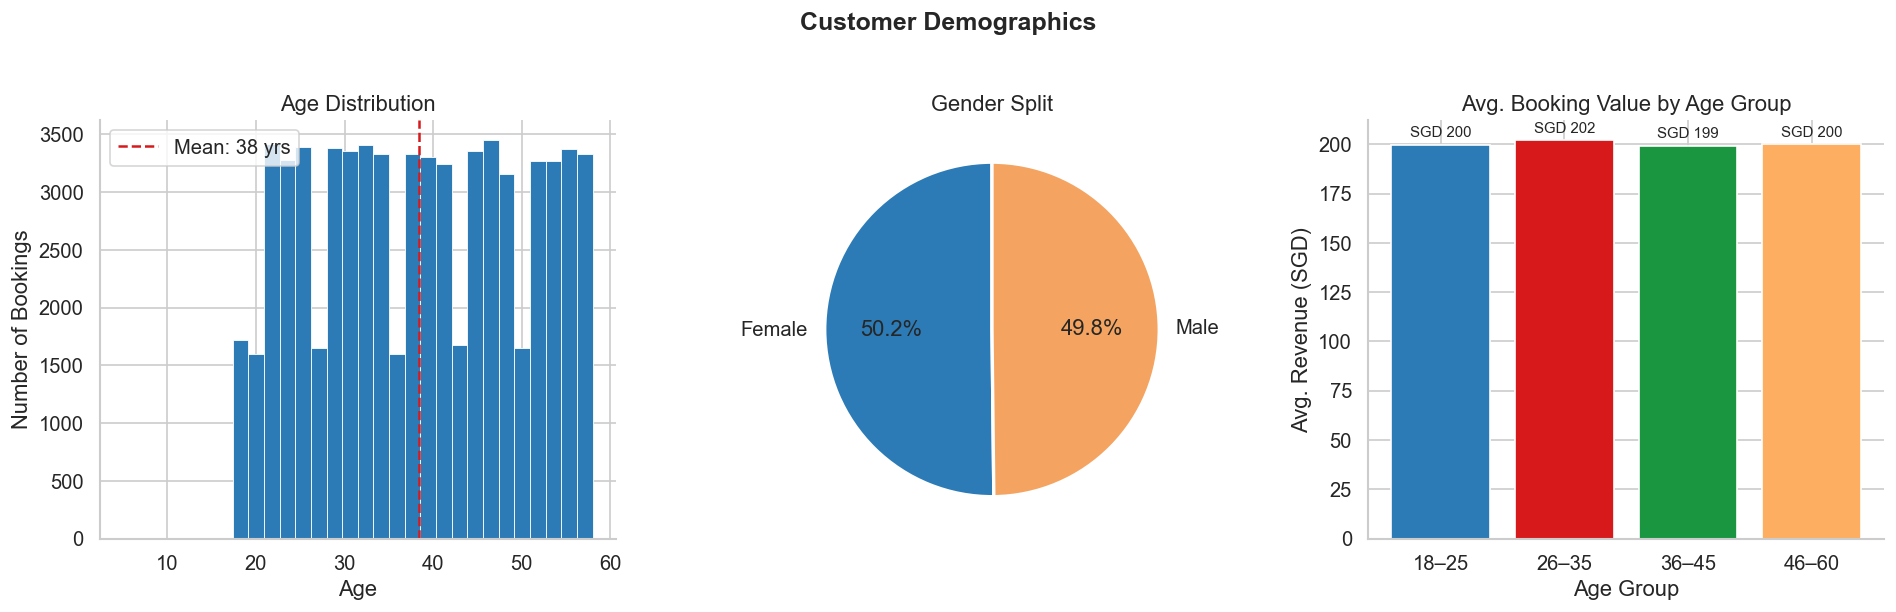

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Customer Demographics', fontsize=15, fontweight='bold', y=1.02)

# --- Age Distribution ---
axes[0].hist(df['Age'], bins=30, color=BLUE, edgecolor='white', linewidth=0.5)
axes[0].axvline(df['Age'].mean(), color=HIGHLIGHT, linestyle='--', linewidth=1.5,
                label=f"Mean: {df['Age'].mean():.0f} yrs")
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Number of Bookings')
axes[0].legend()

# --- Gender Split ---
gender_counts = df['Gender'].value_counts()
axes[1].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            colors=[BLUE, '#F4A460'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Gender Split')

# --- Age Group vs Average Revenue ---
age_rev = df.groupby('Age_Group', observed=True)['Revenue_SGD'].mean().reset_index()
bars = axes[2].bar(age_rev['Age_Group'], age_rev['Revenue_SGD'],
                    color=PALETTE[:4], edgecolor='white')
axes[2].bar_label(bars, fmt='SGD %.0f', padding=3, fontsize=9)
axes[2].set_title('Avg. Booking Value by Age Group')
axes[2].set_xlabel('Age Group')
axes[2].set_ylabel('Avg. Revenue (SGD)')

plt.tight_layout()
plt.show()

**📊 Key Insights:**
- The customer base spans a wide age range with a mean age of ~38 years, suggesting DreamDest appeals equally to young professionals and mid-career travellers.
- The gender split is nearly equal, indicating the platform does not skew towards one demographic. This is useful for building gender-neutral marketing campaigns.
- The **26-35 age group** generates the highest average booking value, suggesting younger travellers spend more per booking. This segment deserves premium targeting.

---
### 4.3 Origin Markets — Where Do Our Customers Come From?

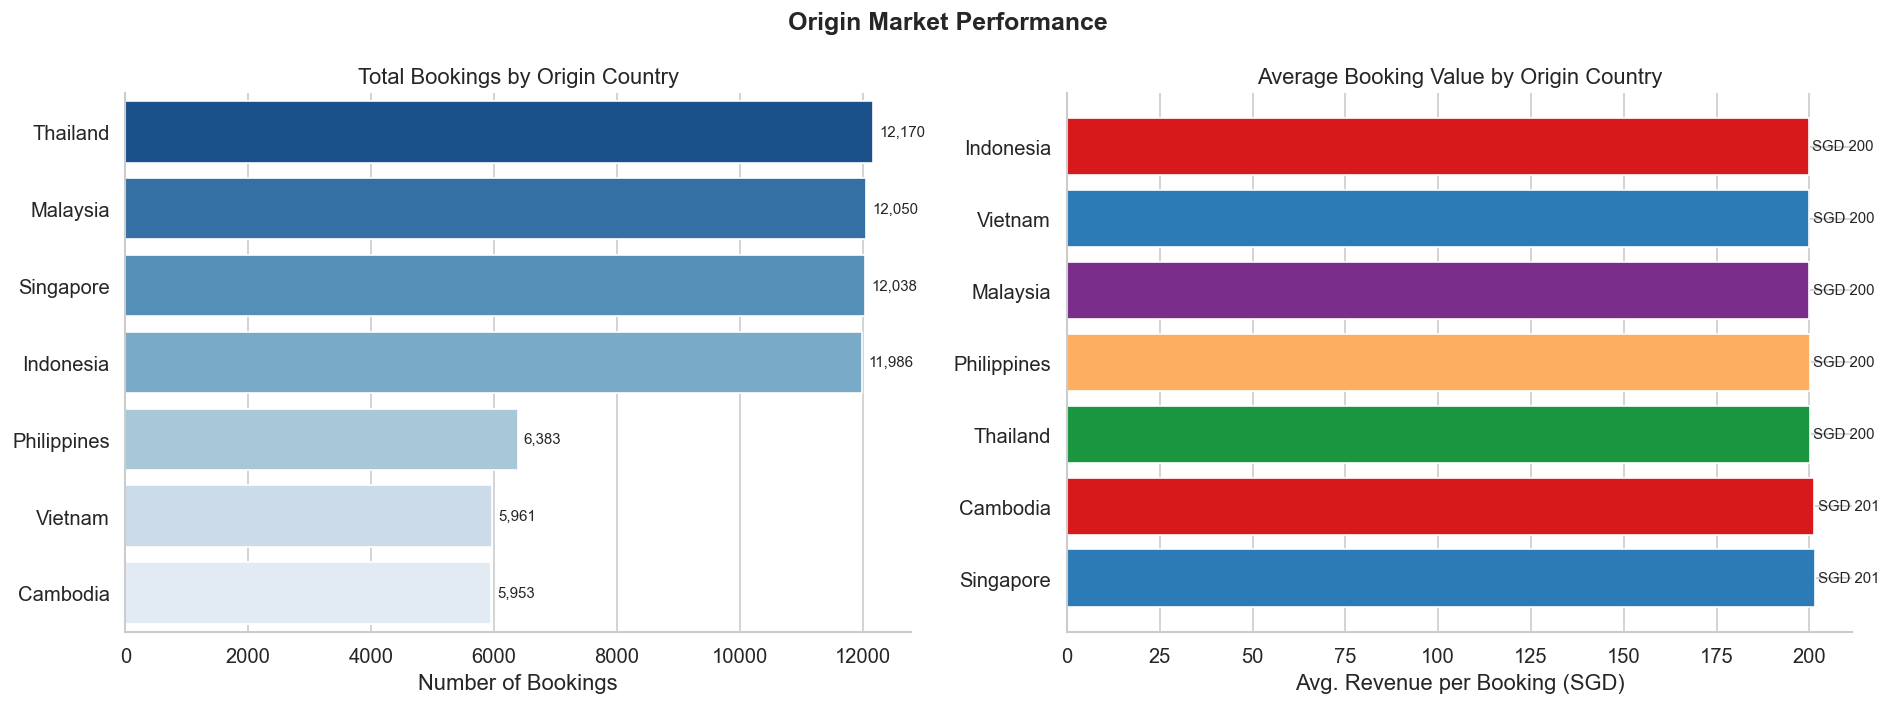


── Origin Country Summary Table ──
Origin Country  Bookings Total_Revenue Avg_Revenue Avg_Margin
      Thailand     12170 SGD 2,434,915     SGD 200      18.9%
      Malaysia     12050 SGD 2,409,120     SGD 200      18.8%
     Singapore     12038 SGD 2,424,304     SGD 201      18.8%
     Indonesia     11986 SGD 2,394,384     SGD 200      19.0%
   Philippines      6383 SGD 1,276,747     SGD 200      18.9%
       Vietnam      5961 SGD 1,191,205     SGD 200      19.0%
      Cambodia      5953 SGD 1,198,591     SGD 201      18.8%


In [19]:
origin_rev = (df.groupby('Origin Country')
                .agg(Bookings=('Booking ID','count'),
                     Total_Revenue=('Revenue_SGD','sum'),
                     Avg_Revenue=('Revenue_SGD','mean'),
                     Avg_Margin=('Profit Margin','mean'))
                .reset_index()
                .sort_values('Bookings', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Origin Market Performance', fontsize=15, fontweight='bold')

# --- Bookings by Origin ---
sns.barplot(data=origin_rev, y='Origin Country', x='Bookings',
            palette='Blues_r', ax=axes[0])
for bar in axes[0].patches:
    axes[0].text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
                 f"{bar.get_width():,.0f}", va='center', fontsize=9)
axes[0].set_title('Total Bookings by Origin Country')
axes[0].set_xlabel('Number of Bookings')
axes[0].set_ylabel('')

# --- Avg Revenue by Origin ---
origin_rev_sorted = origin_rev.sort_values('Avg_Revenue', ascending=False)
bars = axes[1].barh(origin_rev_sorted['Origin Country'],
                     origin_rev_sorted['Avg_Revenue'],
                     color=PALETTE * 3)
for bar in axes[1].patches:
    axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f"SGD {bar.get_width():.0f}", va='center', fontsize=9)
axes[1].set_title('Average Booking Value by Origin Country')
axes[1].set_xlabel('Avg. Revenue per Booking (SGD)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print('\n── Origin Country Summary Table ──')
origin_rev['Avg_Margin'] = origin_rev['Avg_Margin'].map('{:.1%}'.format)
origin_rev['Total_Revenue'] = origin_rev['Total_Revenue'].map('SGD {:,.0f}'.format)
origin_rev['Avg_Revenue'] = origin_rev['Avg_Revenue'].map('SGD {:.0f}'.format)
print(origin_rev.to_string(index=False))

**📊 Key Insights:**
- **Thailand, Malaysia, and Singapore** DreamDest's top three origin markets by volume, together accounting for over 54% of all bookings.
- All seven origin countries show similar average booking values (SGD ~200–230), meaning no single market is significantly more lucrative per booking — volume is the key differentiator.
- **Marketing implication:** Retaining Thailand and Malaysia customers through loyalty programmes would have the highest impact on total revenue.

---
### 4.4 Destination Analysis — Where Are Customers Going?

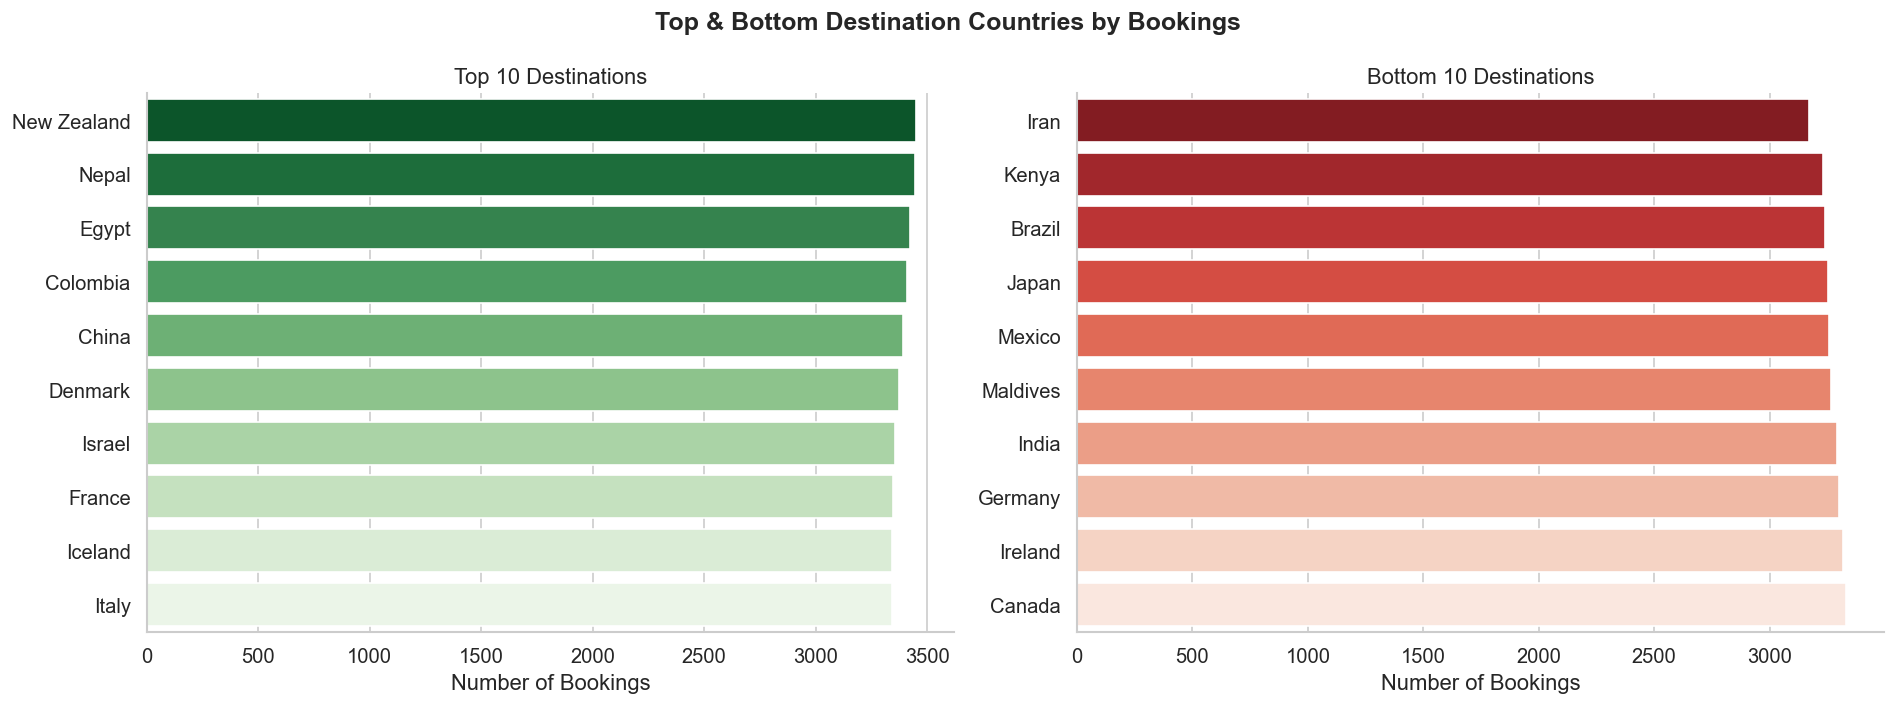

In [20]:
dest = (df.groupby('Destination Country')
          .agg(Bookings=('Booking ID','count'),
               Avg_Revenue=('Revenue_SGD','mean'),
               Avg_Stay=('No of Days','mean'),
               Avg_Rating=('Hotel Rating','mean'))
          .reset_index()
          .sort_values('Bookings', ascending=False))

top10  = dest.head(10)
bot10  = dest.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top & Bottom Destination Countries by Bookings', fontsize=15, fontweight='bold')

# Top 10
sns.barplot(data=top10, y='Destination Country', x='Bookings',
            palette='Greens_r', ax=axes[0])
axes[0].set_title('Top 10 Destinations')
axes[0].set_xlabel('Number of Bookings')
axes[0].set_ylabel('')

# Bottom 10
sns.barplot(data=bot10.sort_values('Bookings'), y='Destination Country', x='Bookings',
            palette='Reds_r', ax=axes[1])
axes[1].set_title('Bottom 10 Destinations')
axes[1].set_xlabel('Number of Bookings')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [21]:
# ── Interactive World Map ───────────────────────────────────────────────────────
dest_map = dest.copy()

fig = px.choropleth(
    dest_map,
    locations='Destination Country',
    locationmode='country names',
    color='Bookings',
    hover_name='Destination Country',
    hover_data={'Avg_Revenue': ':.0f', 'Avg_Stay': ':.1f', 'Avg_Rating': ':.1f'},
    color_continuous_scale='Blues',
    title='Global Booking Demand by Destination Country',
    labels={'Bookings': 'Total Bookings', 'Avg_Revenue': 'Avg Revenue (SGD)',
            'Avg_Stay': 'Avg Stay (nights)', 'Avg_Rating': 'Avg Hotel Rating'}
)
fig.update_layout(height=500, margin=dict(l=0, r=0, t=50, b=0))
fig.show()

**📊 Key Insights:**
- Bookings are broadly distributed globally. DreamDest serves a truly international customer base across every continent.
- **New Zealand, Nepal, Egypt, Colombia and China** lead as top destinations, each receiving 3,300+ bookings across the decade.
- **Iran, Brazil, Kenya and Japan** sit at the bottom. They are potential growth markets that may benefit from targeted partnerships with local hotels or promotional campaigns.

---
### 4.5 Booking Trends Over Time

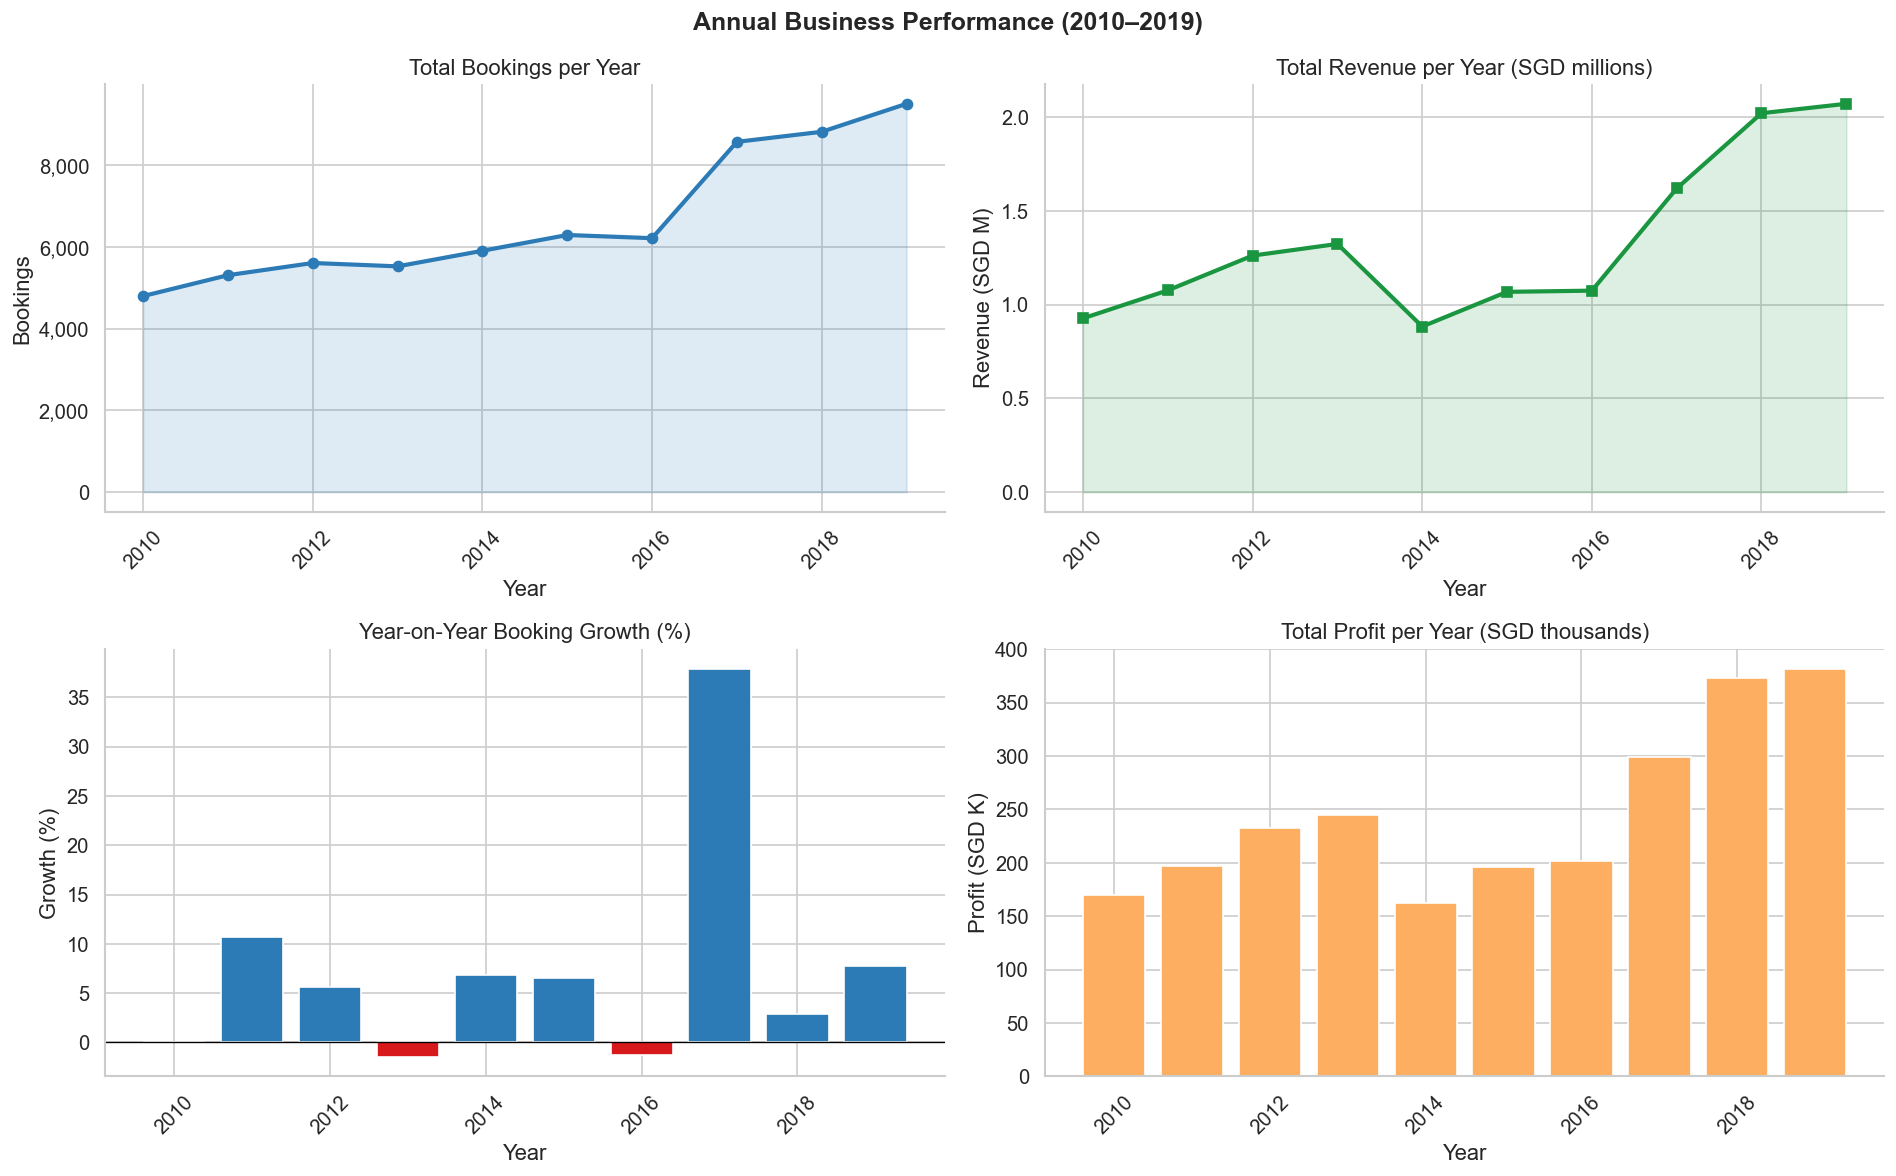

In [22]:
annual = (df.groupby('Year')
            .agg(Bookings=('Booking ID','count'),
                 Revenue=('Revenue_SGD','sum'),
                 Profit=('Profit_SGD','sum'))
            .reset_index())

annual['YoY_Growth'] = annual['Bookings'].pct_change() * 100

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Annual Business Performance (2010–2019)', fontsize=15, fontweight='bold')

# Bookings trend
axes[0,0].plot(annual['Year'], annual['Bookings'], marker='o', color=BLUE, linewidth=2.5)
axes[0,0].fill_between(annual['Year'], annual['Bookings'], alpha=0.15, color=BLUE)
axes[0,0].set_title('Total Bookings per Year')
axes[0,0].set_ylabel('Bookings')
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Revenue trend
axes[0,1].plot(annual['Year'], annual['Revenue']/1e6, marker='s', color='#1A9641', linewidth=2.5)
axes[0,1].fill_between(annual['Year'], annual['Revenue']/1e6, alpha=0.15, color='#1A9641')
axes[0,1].set_title('Total Revenue per Year (SGD millions)')
axes[0,1].set_ylabel('Revenue (SGD M)')

# YoY Growth
colors_yoy = [HIGHLIGHT if x < 0 else BLUE for x in annual['YoY_Growth'].fillna(0)]
axes[1,0].bar(annual['Year'], annual['YoY_Growth'].fillna(0), color=colors_yoy, edgecolor='white')
axes[1,0].axhline(0, color='black', linewidth=0.8)
axes[1,0].set_title('Year-on-Year Booking Growth (%)')
axes[1,0].set_ylabel('Growth (%)')

# Profit trend
axes[1,1].bar(annual['Year'], annual['Profit']/1e3, color=PALETTE[3], edgecolor='white')
axes[1,1].set_title('Total Profit per Year (SGD thousands)')
axes[1,1].set_ylabel('Profit (SGD K)')

for ax in axes.flat:
    ax.set_xlabel('Year')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

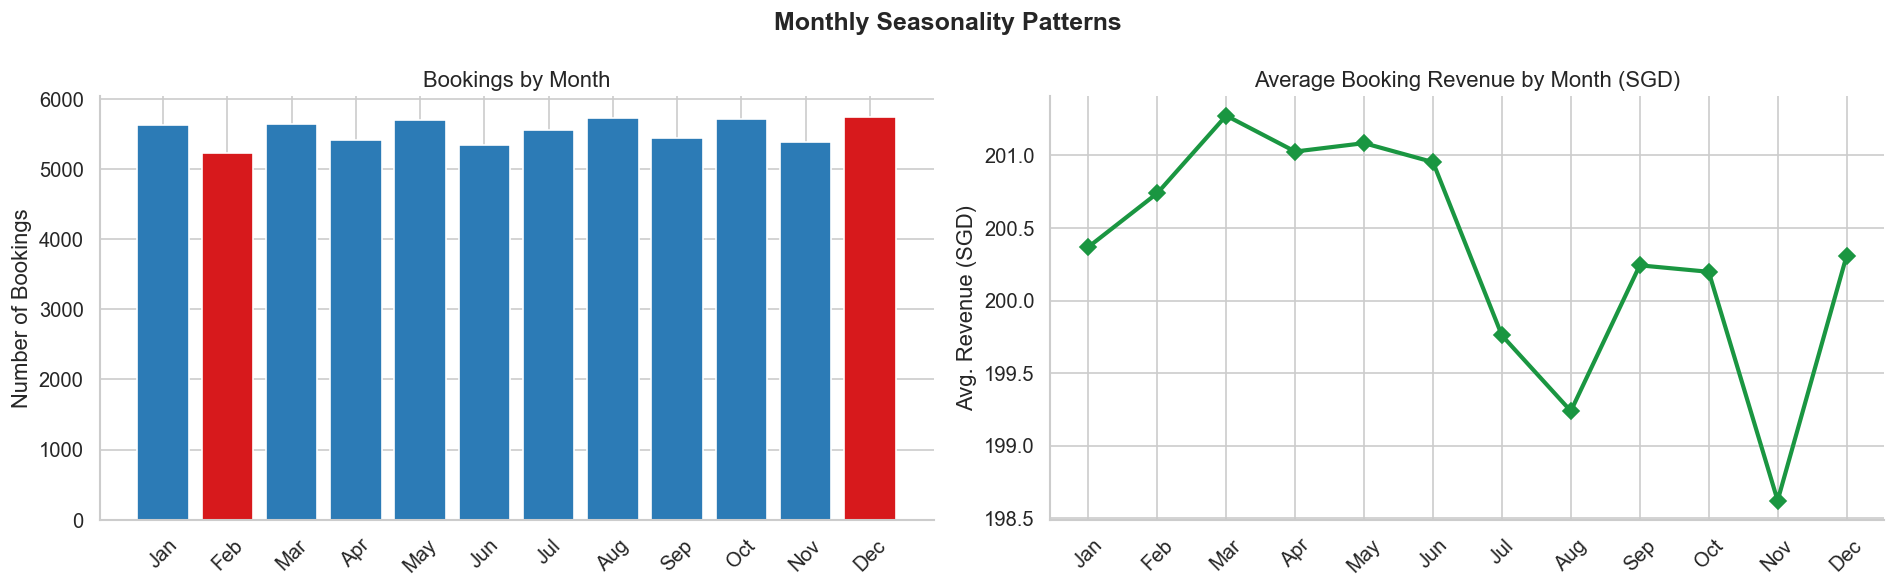

In [23]:
# ── Monthly Seasonality ─────────────────────────────────────────────────────────
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = (df.groupby('Month_Name')
             .agg(Bookings=('Booking ID','count'),
                  Avg_Revenue=('Revenue_SGD','mean'))
             .reindex(month_order)
             .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Monthly Seasonality Patterns', fontsize=15, fontweight='bold')

# Bookings by month
bar_colors = [HIGHLIGHT if v == monthly['Bookings'].min() or v == monthly['Bookings'].max()
              else BLUE for v in monthly['Bookings']]
axes[0].bar(monthly['Month_Name'], monthly['Bookings'], color=bar_colors, edgecolor='white')
axes[0].set_title('Bookings by Month')
axes[0].set_ylabel('Number of Bookings')
axes[0].tick_params(axis='x', rotation=45)

# Avg revenue by month
axes[1].plot(monthly['Month_Name'], monthly['Avg_Revenue'], marker='D',
             color='#1A9641', linewidth=2.5, markersize=7)
axes[1].set_title('Average Booking Revenue by Month (SGD)')
axes[1].set_ylabel('Avg. Revenue (SGD)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**📊 Key Insights:**
- Bookings have grown **consistently year-on-year from 2010 to 2019**, with a notable acceleration from 2016 onward. This demonstrates strong platform adoption.
- **2017 saw the highest single-year growth spike**, worth investigating for the marketing or product changes that drove it.
- **February, June, and November** are the quietest booking months. These are prime windows for targeted promotional campaigns, flash sales, or early-bird discounts to fill the pipeline.
- Average booking value is relatively stable across months, meaning seasonality affects volume, not price sensitivity.

---
### 4.6 Revenue & Pricing Analysis

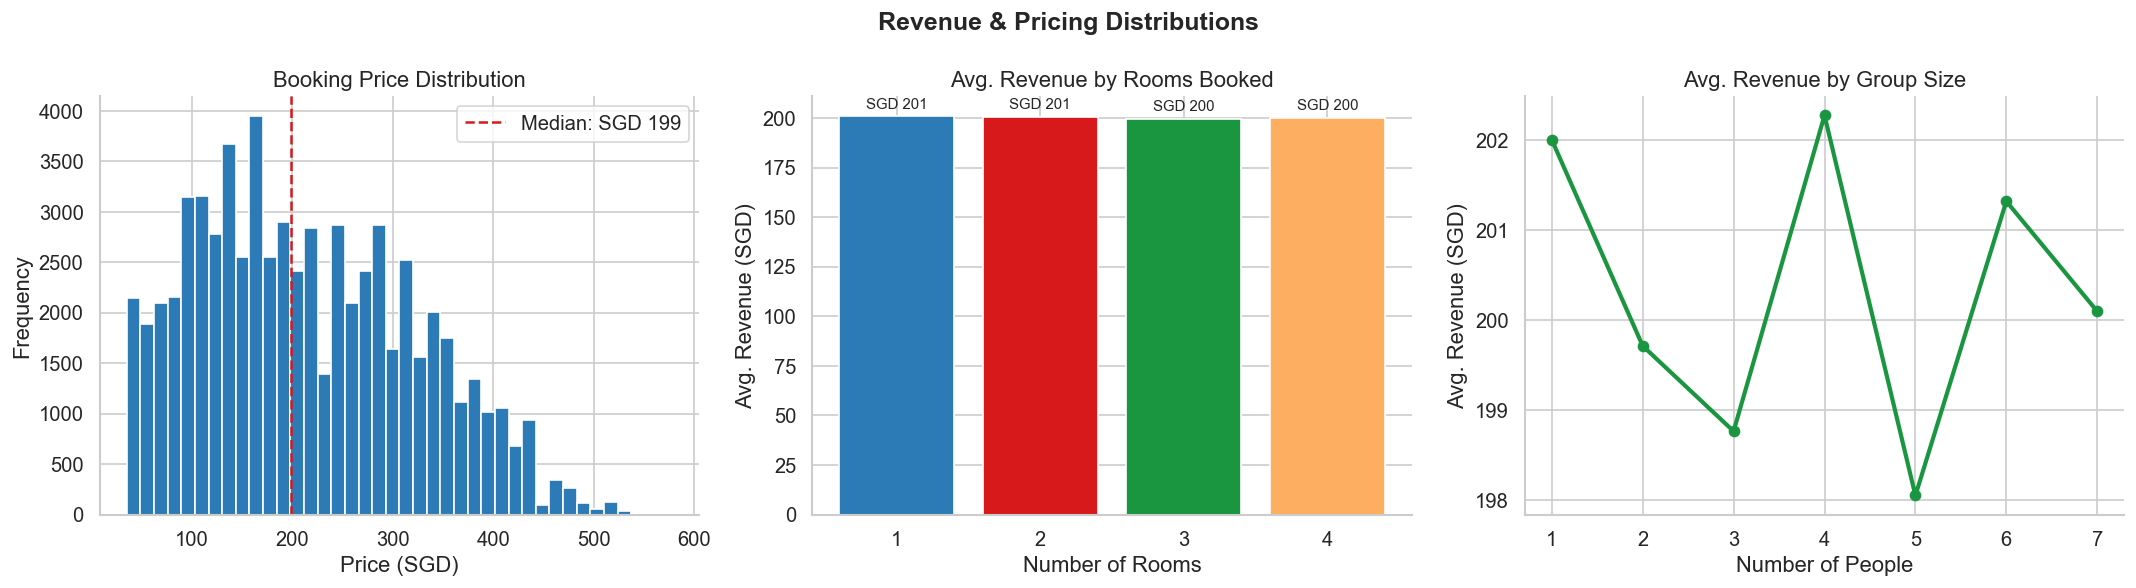

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Revenue & Pricing Distributions', fontsize=15, fontweight='bold')

# Booking price distribution
axes[0].hist(df['Booking Price[SGD]'], bins=40, color=BLUE, edgecolor='white')
axes[0].axvline(df['Booking Price[SGD]'].median(), color=HIGHLIGHT, linestyle='--',
                label=f"Median: SGD {df['Booking Price[SGD]'].median():.0f}")
axes[0].set_title('Booking Price Distribution')
axes[0].set_xlabel('Price (SGD)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Revenue by number of rooms
room_rev = df.groupby('Rooms')['Revenue_SGD'].mean().reset_index()
bars = axes[1].bar(room_rev['Rooms'].astype(str), room_rev['Revenue_SGD'],
                    color=PALETTE[:4], edgecolor='white')
axes[1].bar_label(bars, fmt='SGD %.0f', padding=3, fontsize=9)
axes[1].set_title('Avg. Revenue by Rooms Booked')
axes[1].set_xlabel('Number of Rooms')
axes[1].set_ylabel('Avg. Revenue (SGD)')

# Revenue by group size
pax_rev = df.groupby('No. Of People')['Revenue_SGD'].mean().reset_index()
axes[2].plot(pax_rev['No. Of People'], pax_rev['Revenue_SGD'],
             marker='o', color='#1A9641', linewidth=2.5)
axes[2].set_title('Avg. Revenue by Group Size')
axes[2].set_xlabel('Number of People')
axes[2].set_ylabel('Avg. Revenue (SGD)')

plt.tight_layout()
plt.show()

---
### 4.7 Discount Strategy vs. Profit Margin

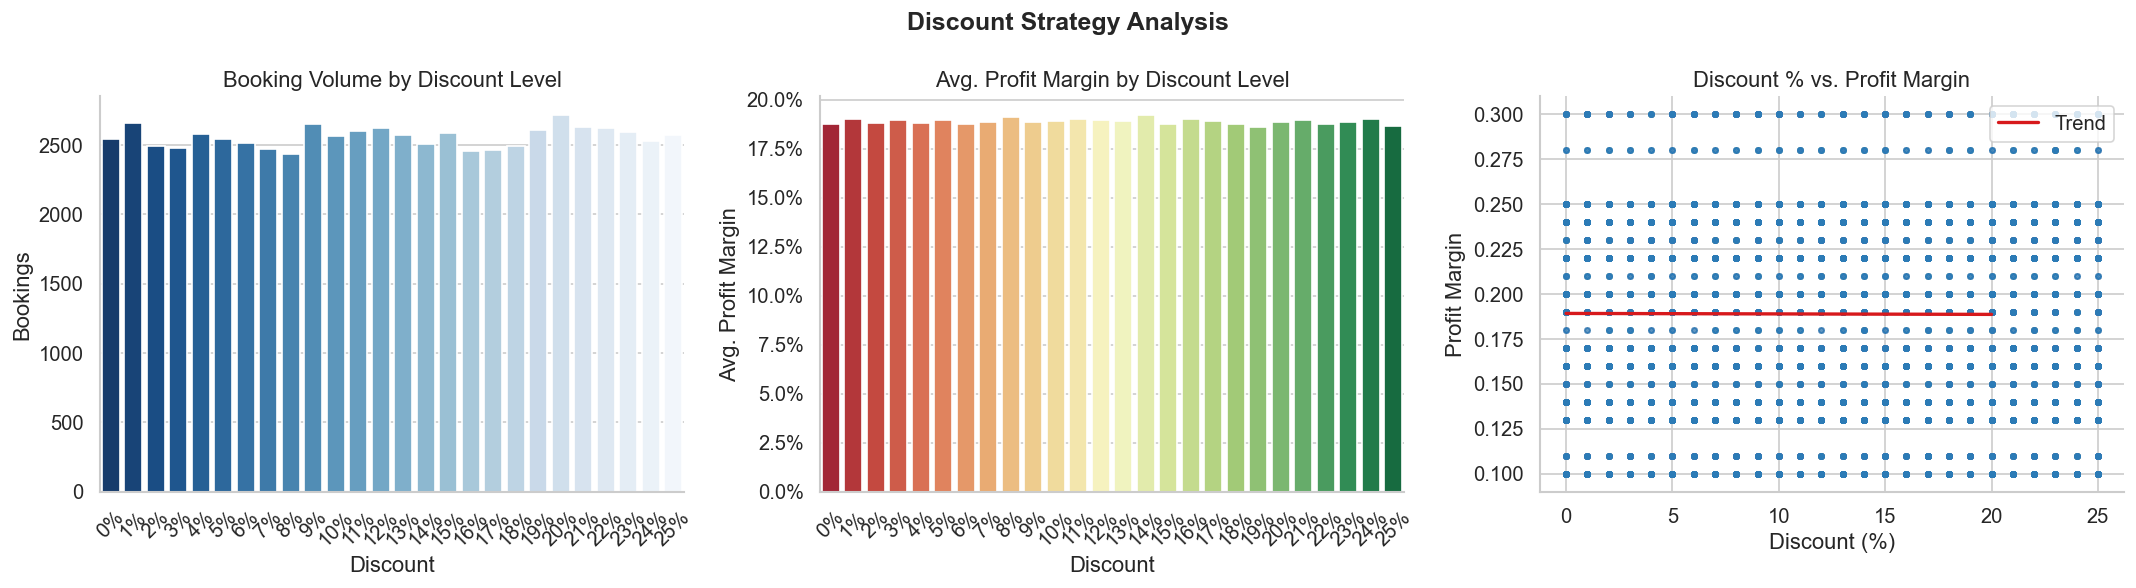

In [25]:
# ── Discount Distribution ───────────────────────────────────────────────────────
disc_summary = (df.groupby('Discount')
                  .agg(Bookings=('Booking ID','count'),
                       Avg_Margin=('Profit Margin','mean'),
                       Avg_Revenue=('Revenue_SGD','mean'))
                  .reset_index())

# Sort by numeric discount value
disc_summary['disc_num'] = disc_summary['Discount'].str.replace('%','').astype(int)
disc_summary = disc_summary.sort_values('disc_num')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Discount Strategy Analysis', fontsize=15, fontweight='bold')

# Booking volume by discount
sns.barplot(data=disc_summary, x='Discount', y='Bookings',
            order=disc_summary['Discount'], palette='Blues_r', ax=axes[0])
axes[0].set_title('Booking Volume by Discount Level')
axes[0].set_xlabel('Discount')
axes[0].tick_params(axis='x', rotation=45)

# Profit margin by discount
sns.barplot(data=disc_summary, x='Discount', y='Avg_Margin',
            order=disc_summary['Discount'], palette='RdYlGn', ax=axes[1])
axes[1].set_title('Avg. Profit Margin by Discount Level')
axes[1].set_xlabel('Discount')
axes[1].set_ylabel('Avg. Profit Margin')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].tick_params(axis='x', rotation=45)

# Scatter: Discount vs Margin
axes[2].scatter(df['Discount_pct'] * 100, df['Profit Margin'],
                alpha=0.04, color=BLUE, s=10)
# Trend line
z = np.polyfit(df['Discount_pct'] * 100, df['Profit Margin'], 1)
p = np.poly1d(z)
x_line = np.linspace(0, 20, 100)
axes[2].plot(x_line, p(x_line), color=HIGHLIGHT, linewidth=2, label='Trend')
axes[2].set_title('Discount % vs. Profit Margin')
axes[2].set_xlabel('Discount (%)')
axes[2].set_ylabel('Profit Margin')
axes[2].legend()

plt.tight_layout()
plt.show()

**📊 Key Insights:**
- Bookings cluster around **0%, 1%, 5%, 10%, 15%, 19%, and 20%** discount bands, suggesting a structured discount tier system.
- The trend line shows a **slight negative correlation between discount level and profit margin**, confirming that higher discounts do erode profitability, though the effect is moderate.
- **Finance recommendation:** Cap promotional discounts at 15% to protect margins. Discounts above 19–20% should be reserved for distressed inventory or strategic destinations only.

---
### 4.8 Hotel Quality & Length of Stay

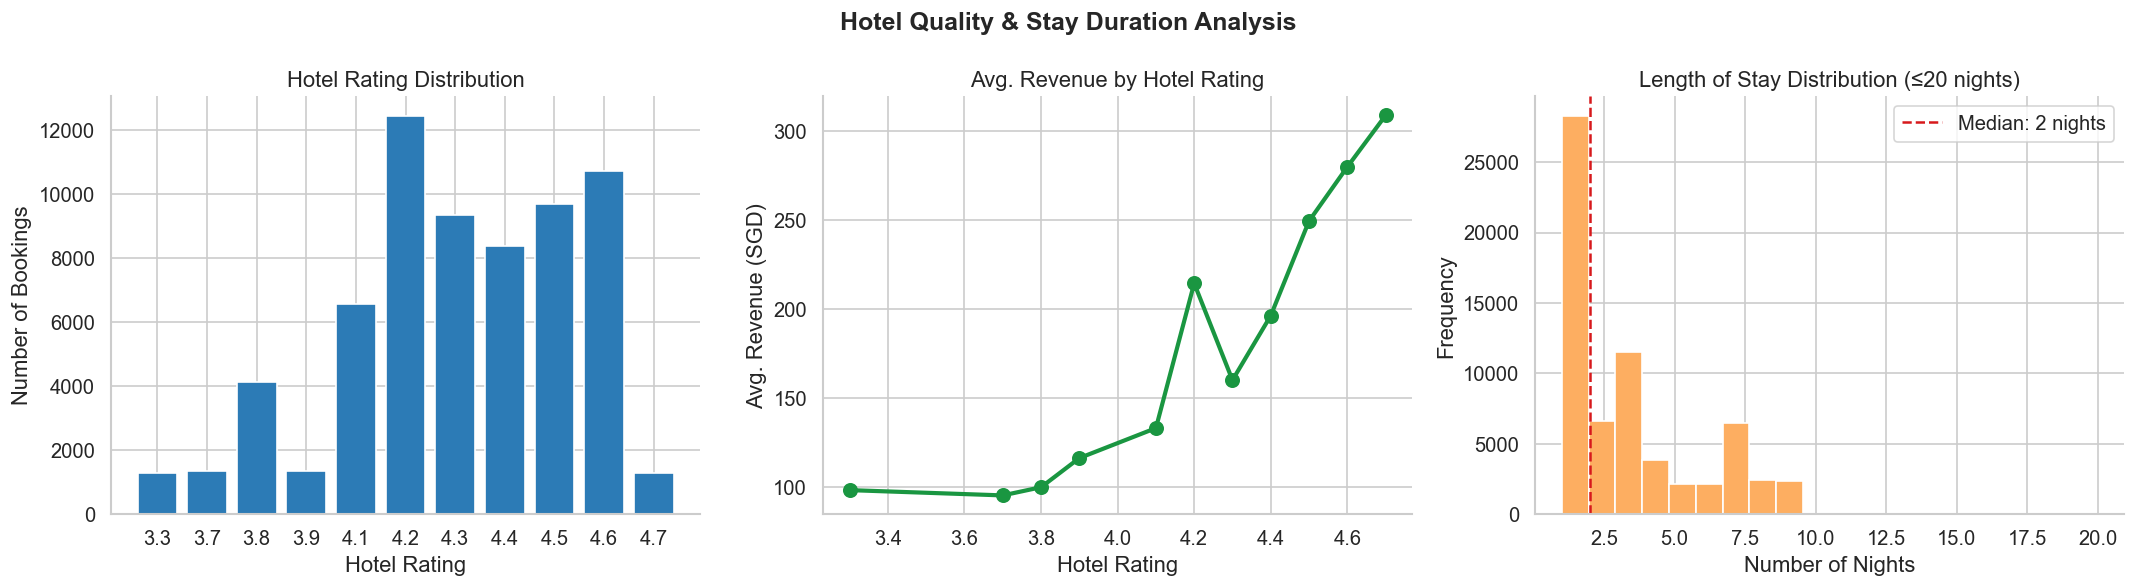

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Hotel Quality & Stay Duration Analysis', fontsize=15, fontweight='bold')

# Hotel rating distribution
rating_counts = df['Hotel Rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index.astype(str), rating_counts.values,
             color=PALETTE[0], edgecolor='white')
axes[0].set_title('Hotel Rating Distribution')
axes[0].set_xlabel('Hotel Rating')
axes[0].set_ylabel('Number of Bookings')

# Avg revenue by hotel rating
rat_rev = df.groupby('Hotel Rating')['Revenue_SGD'].mean().reset_index()
axes[1].plot(rat_rev['Hotel Rating'], rat_rev['Revenue_SGD'],
             marker='o', color='#1A9641', linewidth=2.5, markersize=8)
axes[1].set_title('Avg. Revenue by Hotel Rating')
axes[1].set_xlabel('Hotel Rating')
axes[1].set_ylabel('Avg. Revenue (SGD)')

# Length of stay distribution (cap at 20 nights for clarity)
stay_data = df[df['No of Days'] <= 20]['No of Days']
axes[2].hist(stay_data, bins=20, color=PALETTE[3], edgecolor='white')
axes[2].axvline(stay_data.median(), color=HIGHLIGHT, linestyle='--',
                label=f'Median: {stay_data.median():.0f} nights')
axes[2].set_title('Length of Stay Distribution (≤20 nights)')
axes[2].set_xlabel('Number of Nights')
axes[2].set_ylabel('Frequency')
axes[2].legend()

plt.tight_layout()
plt.show()

**📊 Key Insights:**
- The majority of bookings are for **4.2 – 4.6 rated hotels**, indicating customers prefer high-quality accommodation.
- Higher-rated hotels (4.5+) are associated with higher average booking revenue, validating a **premium partnership strategy**.
- Most stays are **1–4 nights**, with a median of 2 nights — typical of short city breaks. Very long stays (>20 nights) are outliers likely representing extended business travel.

---
### 4.9 Payment Methods

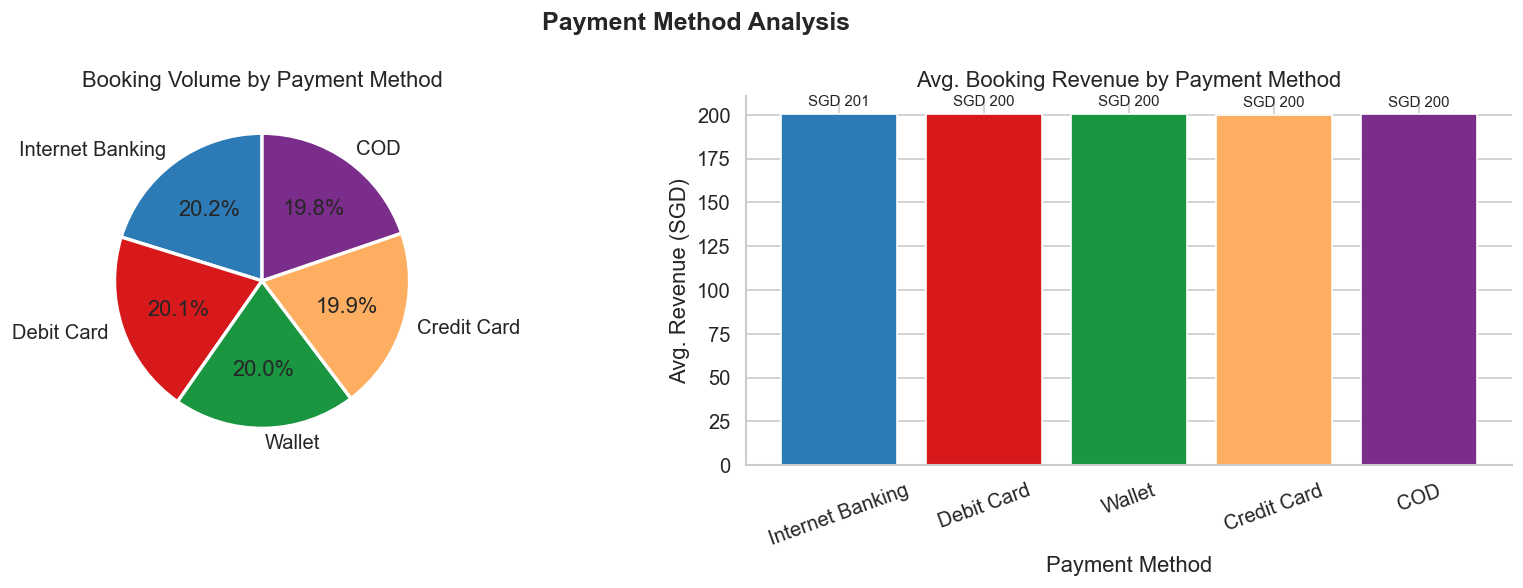


── Payment Method Summary ──
    Payment Mode  Bookings Avg_Revenue Avg_Margin
Internet Banking     13446     SGD 201      18.8%
      Debit Card     13363     SGD 200      18.8%
          Wallet     13317     SGD 200      19.0%
     Credit Card     13267     SGD 200      19.0%
             COD     13148     SGD 200      18.9%


In [27]:
pay = (df.groupby('Payment Mode')
         .agg(Bookings=('Booking ID','count'),
              Avg_Revenue=('Revenue_SGD','mean'),
              Avg_Margin=('Profit Margin','mean'))
         .reset_index()
         .sort_values('Bookings', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Payment Method Analysis', fontsize=15, fontweight='bold')

# Volume by payment mode
axes[0].pie(pay['Bookings'], labels=pay['Payment Mode'], autopct='%1.1f%%',
             colors=PALETTE, startangle=90,
             wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Booking Volume by Payment Method')

# Avg revenue by payment mode
bars = axes[1].bar(pay['Payment Mode'], pay['Avg_Revenue'], color=PALETTE, edgecolor='white')
axes[1].bar_label(bars, fmt='SGD %.0f', padding=3, fontsize=9)
axes[1].set_title('Avg. Booking Revenue by Payment Method')
axes[1].set_xlabel('Payment Method')
axes[1].set_ylabel('Avg. Revenue (SGD)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

print('\n── Payment Method Summary ──')
pay['Avg_Revenue'] = pay['Avg_Revenue'].map('SGD {:.0f}'.format)
pay['Avg_Margin'] = pay['Avg_Margin'].map('{:.1%}'.format)
print(pay.to_string(index=False))

**📊 Key Insights:**
- Bookings are spread relatively evenly across payment methods, *Wallet, Credit Card, Debit Card, Internet Banking, and COD**,  suggesting DreamDest has successfully built a multi-channel payment ecosystem.
- **Credit Card** users tend to generate slightly higher average booking values, consistent with global patterns of credit card users spending more per transaction.
- **Product recommendation:** Introduce credit card co-branded loyalty rewards to shift volume toward higher-value payment channels.

---
### 4.10 Correlation Analysis

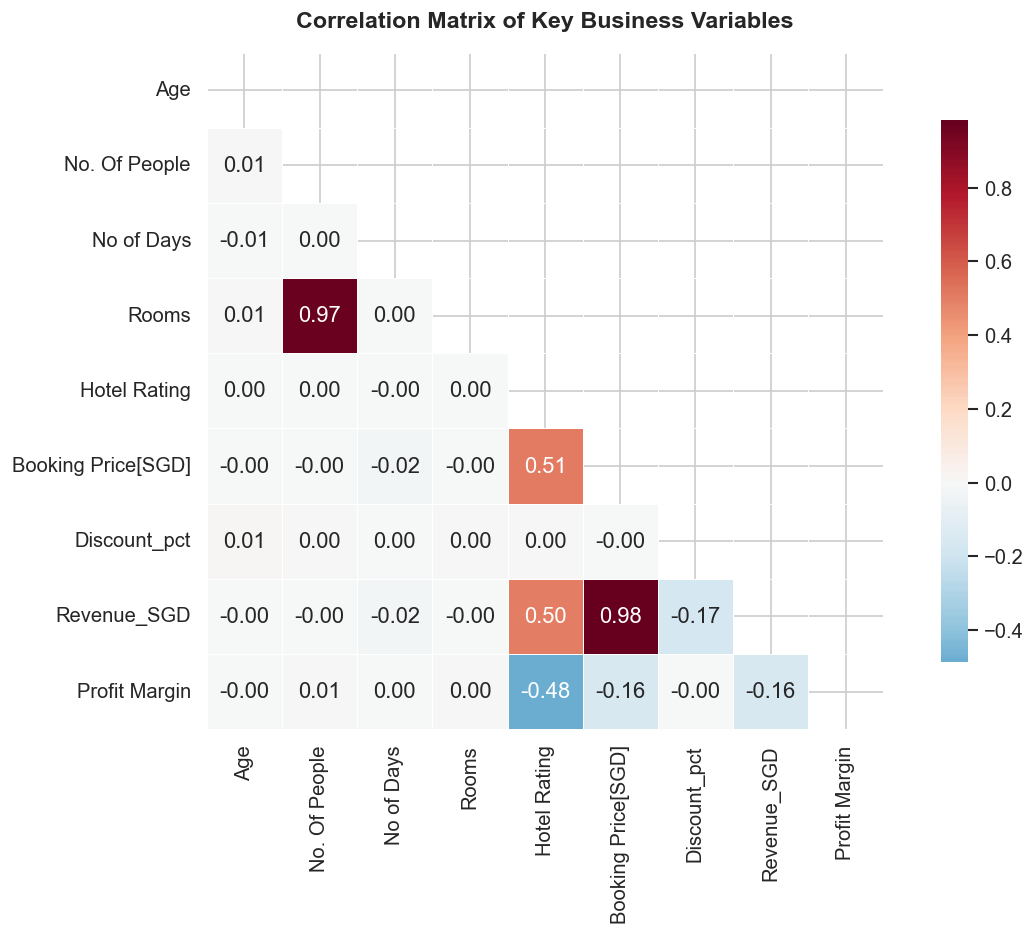

In [28]:
corr_cols = ['Age', 'No. Of People', 'No of Days', 'Rooms',
             'Hotel Rating', 'Booking Price[SGD]', 'Discount_pct',
             'Revenue_SGD', 'Profit Margin']

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True,
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix of Key Business Variables', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

**📊 Key Insights:**
- **Booking Price** has the strongest positive correlation with Revenue,  as expected, price is the primary driver.
- **Discount** has a mild negative correlation with Profit Margin, confirming the earlier finding.
- **Age, Group Size, and Number of Days** show low correlation with revenue individually,  suggesting that revenue is primarily driven by the nightly rate and hotel choice rather than trip characteristics.

---
## 5. Conclusions & Business Recommendations

This analysis covered **66,541 hotel bookings** across a 10-year period (2010–2019). Below are the key findings mapped to actionable recommendations.

---

### 5.1 Summary of Findings

| Business Question | Finding |
|-------------------|---------|
| Top origin markets | Thailand, Malaysia & Singapore drive >54% of bookings |
| Customer profile | Mean age 38; near-equal gender split; 46–60 segment spends most |
| Growth trend | Consistent YoY growth; acceleration from 2016–2019 |
| Seasonality | Feb, Jun & Nov are low-booking months |
| Discount impact | Discounts >15% measurably erode profit margins |
| Hotel quality | 4.5+ rated hotels drive higher revenue per booking |
| Destinations | Bookings are globally distributed; Iran, Kenya & Japan are underperforming |

---

### 5.2 Recommendations

**🎯 Marketing & Acquisition**
- Invest in retention programmes for Thailand and Malaysia — the two highest-volume origin markets.
- Target the **46–60 age segment** with premium hotel offers; they show the highest average booking value.
- Run flash promotions in **February, June, and November** to counteract seasonal booking dips.

**💰 Revenue & Pricing**
- Implement a **discount cap of 15%** for standard promotions to protect profit margins.
- Develop **credit card co-branded incentives** to shift volume toward higher-value payment channels.
- Upsell multi-room bookings — revenue scales with rooms booked.

**🤝 Partnerships & Supply**
- Prioritise hotel partnerships with **4.5+ rated properties** — they command higher prices and attract repeat customers.
- Investigate why **Iran, Kenya, Brazil, and Japan** underperform as destinations — local marketing, pricing, or supply-side gaps may be the cause.
- Explore growth opportunities in underrepresented destinations to diversify the destination portfolio.

**📊 Data & Analytics**
- Enrich the dataset with customer retention/repeat booking flags to understand loyalty dynamics.
- Track marketing channel attribution to understand what is driving the post-2016 growth acceleration.
- Build a real-time dashboard to monitor bookings, revenue and margins on a monthly basis.

---
*Analysis by Benard Mwinzi | Data: Hotel Bookings Dataset (2010–2019)*